In [17]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import xarray as xr
import matplotlib.pyplot as plt
from functions.convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds 

In [56]:
nc_in = r'O:\HybridDune experiment\data lidar netcdf\S2 Lidar, storm1.nc'

t_start = pd.Timestamp('2024-12-19 04:10')
t_stop = pd.Timestamp('2024-12-19 06:10')
ds = xr.open_dataset(nc_in).sel(t=slice(t_start, t_stop)).isel( profile_number=slice(2,3), obs_number=362)                                            # select specific time range
#ds = xr.open_dataset(nc_in).isel( t=slice(0,1), profile_number=slice(2,3), obs_number=slice(0,360)) # select only the first timestep, the first 360 observations and profile 2 (starting from 0), i.e. perpendicular to shore

# Convert coordinates to local coordinate system, extract variables for plotting 
# A function is supplied to convert the coordinates, from relative to the lidar to local or RD coordinate system. Open it for details
ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=False, keep_r=False, keep_y=True) # load all echos, skip intensity, drop r, keep y_local
x = ds.x.values.squeeze()
y = ds.y.values.squeeze()
z = ds.z.values.squeeze()


In [59]:
x.shape
# y
# z
# ds.x_i_local.values
#ds.y_i_local.values



(28766,)

(1.4, 2.8)

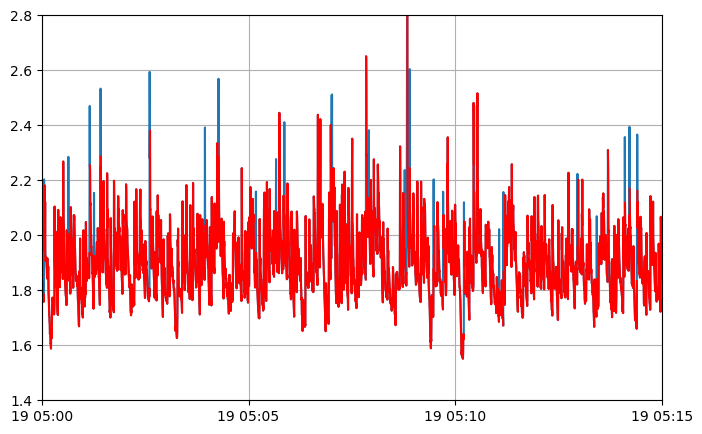

In [92]:
# filter dz: 
dz_forward = np.diff(z, prepend=np.nan)   # z[i] - z[i-1]
dz_backward = np.diff(z, append=np.nan)   # z[i+1] - z[i]

mask = (np.abs(dz_forward) >= 0.2) & (np.abs(dz_backward) >= 0.2)

z_filtered = z.copy()
z_filtered[mask] = np.nan


# plot t vs z
plt.figure(figsize=(8,5))
plt.plot(ds.t.values, z)
plt.plot(ds.t.values, z_filtered, 'r')
plt.grid()
plt.xlim(pd.Timestamp('2024-12-19 05:00'), pd.Timestamp('2024-12-19 05:15'))
plt.ylim(1.4,2.8)

In [69]:
dz.shape
dz_filtered.shape

(27062,)

(array([1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        5.0000e+00, 6.0000e+00, 1.2000e+01, 1.5000e+01, 2.7000e+01,
        4.9000e+01, 6.8000e+01, 1.0200e+02, 1.5100e+02, 2.2400e+02,
        6.4100e+02, 3.3750e+03, 1.5428e+04, 5.8800e+03, 1.0020e+03,
        5.1700e+02, 3.5400e+02, 2.5300e+02, 1.7800e+02, 1.0500e+02,
        7.5000e+01, 6.6000e+01, 5.1000e+01, 5.1000e+01, 4.3000e+01,
        2.7000e+01, 1.8000e+01, 1.3000e+01, 7.0000e+00, 6.0000e+00,
        3.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-0.68798685, -0.65792745, -0.627868  , -0.5978086 , -0.56774914,
        -0.53768975, -0.50763035, -0.47757089, -0.44751146, -0.41745204,
        -0.38739261, -0.35733318, -0.32727379, -0.29721436, -0.26715493,
        -0.2370955 , -0.20703608, -0.17697668, -0.14691722, -0.11685783,
        -0.08679837, -0.05

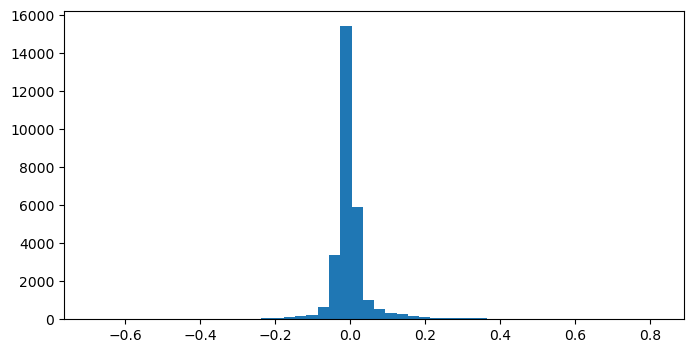

In [66]:
dz = np.diff(z)

# mean abs dz
#mean_abs_dz = np.mean(np.abs(dz))
#mean_abs_dz

# plot a histogram of dz
plt.figure(figsize=(8,4))
plt.hist(dz, bins=50)